# prompt apos diversos testes do prompt 8 decidi voltar pro prompt 7 pra manter drops menos agressivo

also changed the code structure!

Net effect summary
Dimension	Before	Now
Index safety	❌ fragile	✅ correct
Crash risk	⚠️ medium	✅ low
Anchor stability	⚠️ noisy	✅ strong
Manager leakage	❌ high	✅ controlled
IT leakage	⚠️ uneven	✅ bounded
Scale readiness	❌ risky	✅ safe for 28M

# Helpers

In [1]:
import json
import re
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
_RUN_RE = re.compile(
    r"llama_drop_only_(?P<month>adzuna_month\d{2})_(?P<start>\d+)_(?P<stop>\d+)_job(?P<jobid>\d+)_task(?P<taskid>\d+)_\d{8}_\d{6}\.jsonl$"
)

IT_PATTERNS = [
    r"\bsoftware\b", r"\bdeveloper\b", r"\bengineer\b", r"\bdata\b", r"\bml\b", r"\bai\b",
    r"\bcloud\b", r"\bcyber\b", r"\bsecurity\b", r"\bnetwork\b", r"\bsystems?\b",
    r"\bdatabase\b", r"\bit\b", r"\bdevops\b"
]
_IT_RE = re.compile("|".join(IT_PATTERNS), flags=re.I)

def _is_it_role(title: str) -> bool:
    if not title:
        return False
    return bool(_IT_RE.search(title))


def _infer_npz_from_jsonl(jsonl_path: Path) -> Path:
    """
    NEW layout:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>/llama_drop_only_....jsonl
    NPZ sits at:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>.npz
    """
    m = _RUN_RE.search(jsonl_path.name)
    if not m:
        raise ValueError(f"JSONL filename doesn't match expected pattern: {jsonl_path.name}")

    month = m.group("month")
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    return embed_root / f"{month}.npz"


def _get_job_ids(z) -> np.ndarray:
    """
    Supports both schemas:
      new: job_ids
      old: job_id
    Returns np.ndarray[str]
    """
    if "job_ids" in z.files:
        return z["job_ids"].astype(str)
    if "job_id" in z.files:
        return z["job_id"].astype(str)
    raise KeyError(f"NPZ missing job id key. Need job_ids or job_id. Have={sorted(z.files)}")


def _load_npz_lookup(npz_path: Path):
    """
    Expects stage3-prep NPZ keys (canonical):
      job_ids (or job_id), job_ad_title, job_desc, job_tasks, domain, job_sector_category, job_description
    """
    with np.load(npz_path, allow_pickle=True) as z:
        job_ids = _get_job_ids(z)

        # canonical (your stage3-prep)
        job_ad_title = z["job_ad_title"]
        job_desc = z["job_desc"]
        job_tasks = z["job_tasks"]

        domain = z["domain"] if "domain" in z.files else None
        job_sector_category = z["job_sector_category"] if "job_sector_category" in z.files else None
        job_description = z["job_description"] if "job_description" in z.files else None

    lookup = {}
    for i, jid in enumerate(job_ids):
        lookup[jid] = {
            "job_ad_title": None if job_ad_title[i] is None else str(job_ad_title[i]),
            "job_desc": None if job_desc[i] is None else str(job_desc[i]),
            "job_tasks": None if job_tasks[i] is None else str(job_tasks[i]),
            "job_description": None if job_description is None or job_description[i] is None else str(job_description[i]),
            "domain": None if domain is None or domain[i] is None else str(domain[i]),
            "job_sector_category": None if job_sector_category is None or job_sector_category[i] is None else str(job_sector_category[i]),
        }
    return lookup


# ---------------------------------------------------------------------
# Main: report generator
# ---------------------------------------------------------------------
def gen_report(jsonl_path: str, *, npz_path: str | None = None, sample_n: int = 30, seed: int = 0):
    """
    jsonl_path: path to llama_drop_only_*.jsonl
    npz_path  : optional explicit context NPZ. If None, inferred from jsonl name/dir.
    """
    random.seed(seed)

    jsonl_path = Path(jsonl_path)
    if not jsonl_path.exists():
        raise FileNotFoundError(f"Missing JSONL: {jsonl_path}")

    inferred_npz = _infer_npz_from_jsonl(jsonl_path)
    npz_path = Path(npz_path) if npz_path else inferred_npz
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")

    # report folder: put it under .../llm_negative_selection/<EMBED>/evaluation_reports/
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    report_dir = embed_root / "evaluation_reports"
    report_dir.mkdir(parents=True, exist_ok=True)

    print("JSONL:", jsonl_path)
    print("NPZ :", npz_path)
    print("OUT :", report_dir)

    lookup = _load_npz_lookup(npz_path)

    before_counts = []
    after_counts = []
    kept_titles = Counter()
    domain_kept = defaultdict(list)

    it_leak = 0
    total_kept = 0
    empty_outputs = 0

    samples = []
    seen_sample_ids = set()

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue

            jid = str(r.get("job_id", "")).strip()
            if not jid:
                continue

            ctx = lookup.get(jid, {})

            cand = r.get("candidates") or []
            final = r.get("final") or []

            before_counts.append(len(cand))
            after_counts.append(len(final))

            if len(final) == 0:
                empty_outputs += 1

            for t in final:
                kept_titles[t] += 1
                total_kept += 1
                if _is_it_role(t):
                    it_leak += 1

            dom = ctx.get("domain") or "UNKNOWN"
            domain_kept[dom].append(len(final))

            # sample gate
            if len(samples) < sample_n and jid not in seen_sample_ids and random.random() < 0.05:
                seen_sample_ids.add(jid)
                samples.append({
                    "job_id": jid,
                    "job_ad_title": ctx.get("job_ad_title"),
                    "domain": ctx.get("domain"),
                    "sector": ctx.get("job_sector_category"),
                    "job_desc": ctx.get("job_desc"),
                    "kept": final,
                    "dropped": r.get("drop") or [],
                })

    if not before_counts:
        raise RuntimeError("No valid rows parsed from JSONL.")

    before_avg = statistics.mean(before_counts)
    after_avg = statistics.mean(after_counts)
    drop_rate = 1.0 - (after_avg / before_avg if before_avg else 0.0)
    it_share = it_leak / max(total_kept, 1)

    metrics = {
        "jobs": len(before_counts),
        "avg_candidates_before": round(before_avg, 3),
        "avg_candidates_after": round(after_avg, 3),
        "drop_rate": round(drop_rate, 4),
        "empty_outputs_percent": round(100.0 * empty_outputs / len(before_counts), 3),
        "it_leakage_share": round(it_share, 4),
        "min_kept": int(min(after_counts)),
        "max_kept": int(max(after_counts)),
    }

    domain_summary = {d: round(statistics.mean(v), 3) for d, v in domain_kept.items()}

    report = {
        "run": {
            "jsonl": str(jsonl_path),
            "npz": str(npz_path),
            "generated_at": datetime.now().isoformat(timespec="seconds"),
        },
        "global_metrics": metrics,
        "top_kept_roles": kept_titles.most_common(25),
        "domain_summary_avg_kept": dict(sorted(domain_summary.items(), key=lambda x: (-x[1], x[0]))),
        "sample_cases": samples,
    }

    base = jsonl_path.stem
    report_json = report_dir / f"{base}_report.json"
    report_txt = report_dir / f"{base}_report.txt"

    with report_json.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with report_txt.open("w", encoding="utf-8") as f:
        f.write("=== GLOBAL METRICS ===\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\n=== TOP KEPT OCCUPATIONS ===\n")
        for title, cnt in kept_titles.most_common(25):
            f.write(f"{cnt}  {title}\n")

        f.write("\n=== DOMAIN AVG KEPT ===\n")
        for d, v in sorted(domain_summary.items(), key=lambda x: (-x[1], x[0])):
            f.write(f"{d}: {v}\n")

        f.write("\n=== SAMPLE CASES (truncated) ===\n")
        for s in samples[:10]:
            f.write(f"\njob_id: {s['job_id']}\n")
            f.write(f"title:  {s.get('job_ad_title')}\n")
            f.write(f"domain: {s.get('domain')} | sector: {s.get('sector')}\n")
            f.write(f"kept:   {s.get('kept')}\n")
            f.write(f"drop:   {s.get('dropped')}\n")

    print("\nSaved:")
    print(" ", report_json)
    print(" ", report_txt)

    return report_json, report_txt


# Prompt 9 - calibrating promtp 7

In [2]:
# -*- coding: utf-8 -*-
from pathlib import Path
import numpy as np

# ---- CONFIG ----
NPZ_PATH = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz")
ROW_IDX = 35  # row to inspect

# ---- LOAD ----
data = np.load(NPZ_PATH, allow_pickle=True)

job_ad_title = str(data["job_ad_title"][ROW_IDX])
domain = str(data["domain"][ROW_IDX])
job_sector_category = str(data["job_sector_category"][ROW_IDX])

job_tasks_raw = data["job_tasks"][ROW_IDX]
job_desc = str(data["job_desc"][ROW_IDX]) if "job_desc" in data.files else ""
job_full_ads = data["job_description"][ROW_IDX] if "job_description" in data.files else ""

titles_raw = data["titles"][ROW_IDX]

# ---- CLEAN TITLES (1-based indexing must match prompt) ----
titles_raw = list(titles_raw) if titles_raw is not None else []
clean_titles = [str(t).strip() for t in titles_raw if t and str(t).strip()]
numbered = "\n".join(f"{i+1}. {t}" for i, t in enumerate(clean_titles))

# ---- CLEAN TASKS ----
if isinstance(job_tasks_raw, (list, np.ndarray)):
    tasks_str = ", ".join([str(t).strip() for t in job_tasks_raw if t and str(t).strip()])
else:
    tasks_str = str(job_tasks_raw).strip()

# ---- FULL AD EXCERPT ----
full_text = str(job_full_ads) if job_full_ads is not None else ""
full_excerpt = full_text.strip()[:700] if full_text else ""
full_block = (
    f"\nFULL AD EXCERPT (use for concrete tools/duties only):\n{full_excerpt}\n"
    if full_excerpt else ""
)

# ---- BUILD PROMPT ----
prompt = f"""
TASK
You are a Senior Labor Market Economist. Evaluate candidate occupations and DROP those that are NOT functional matches for the job.

GOAL
- Default: KEEP 2–3 best matches if they plausibly represent valid aspects of the role.
- Keep-floor: If at least 2 candidates are plausibly correct, you MUST KEEP at least 2.
- Selectivity: return exactly 1 ONLY if you are extremely sure all others are clearly incorrect.
- Constraint: Never return 0 candidates. Never return more than 3.

JOB CONTEXT (SOURCE OF TRUTH)
Title: {job_ad_title}
Sector/Domain: {job_sector_category} | {domain}

CORE EVIDENCE (Functional Truth)
Tasks/Skills: {tasks_str}

Secondary (Context)
Short Desc: {job_desc}
{full_block}

CANDIDATES (1-based)
{numbered}

ANCHOR PROTECTION (FUNCTION FIRST)
1) The ANCHOR is the candidate whose FUNCTION best matches the title’s role type (not seniority, not niche specialism).
2) You MUST KEEP the ANCHOR unless CORE EVIDENCE explicitly contradicts it.
3) TITLE KEYWORD LOCK (HARD): If the job title contains a clear functional keyword (e.g. driver, nurse, electrician, installer, developer, android, ios), and a candidate directly matching that function exists, you MUST keep that candidate and MUST NOT replace it with managers, engineers, or specialists.
4) Do NOT replace a general functional match with a niche specialty (e.g. robotics engineer, nanosystems) unless tasks explicitly describe it.

SECONDARY KEEP (CONDITIONAL)
After selecting the ANCHOR, a secondary candidate may be kept ONLY if it is in the same functional family as the ANCHOR (e.g. sommelier ↔ waiter; care worker ↔ home health aide) OR CORE EVIDENCE explicitly mentions duties unique to that occupation. Otherwise, DROP it.

HIERARCHY & IT GATES
1) HARD MANAGER RULE
   - If the title does NOT include Manager, Lead, Head, Director, Supervisor, Team Leader, or Foreman AND CORE EVIDENCE does NOT explicitly describe people management or budgets (supervise, rota, training, audits, performance), you MUST DROP ALL managerial candidates.
   - If explicit oversight evidence exists, you MAY keep ONE manager candidate as a secondary keep.

2) IT DOMAIN LOCK
   - If the title is explicitly IT (developer, software engineer, programmer, frontend/backend, android/ios), DO NOT drop the IT anchor regardless of domain.
   - Otherwise, if Sector/Domain is NOT IT-related, DROP "Software Developer" / "IT Project Manager" UNLESS CORE EVIDENCE mentions building/coding AND at least TWO technical terms (Python/Java/SQL/APIs/Git/React/etc).
   - Simple tool usage (Excel, SAP, internal apps) is NOT IT work.

3) CRAFT PREFERENCE (TIE-BREAK ONLY)
   - Apply ONLY if the title is ambiguous OR multiple candidates are equally plausible.
   - If the title explicitly says "Engineer", do NOT drop the Engineer candidate unless tasks clearly contradict it.

PRUNING RULES
1) Specificity: Keep specialists alongside generic parents if both match the tasks, within the 3 cap.
2) If more than 3 are valid, drop the most generic/vague ones first (broad managers, broad admins, broad "helpers").

ORDER OF OPERATIONS (TIE-BREAKERS)
1. ANCHOR PROTECTION & TITLE LOCK: Highest priority. A clear title keyword overrides all gates.
2. HARD MANAGER RULE: Second priority. Stop seniority drift immediately.
3. DOMAIN GATES: Final noise filter.

RE-ANCHOR (Final Check)
Title: {job_ad_title}
Primary Tasks: {tasks_str}
Keep 2–3 by default. Keep 1 only if extremely sure.

OUTPUT
Return ONLY valid JSON. No text. No explanation.
Schema:
{{"drop":[...]}}
""".strip()

# ---- PRINT ----
print("-" * 80)
print(f"VERIFIED PRODUCTION PROMPT (ROW {ROW_IDX})")
print(f"NPZ: {NPZ_PATH}")
print(f"Candidates: {len(clean_titles)}")
print("-" * 80)
print(prompt)
print("-" * 80)


--------------------------------------------------------------------------------
VERIFIED PRODUCTION PROMPT (ROW 35)
NPZ: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz
Candidates: 6
--------------------------------------------------------------------------------
TASK
You are a Senior Labor Market Economist. Evaluate candidate occupations and DROP those that are NOT functional matches for the job.

GOAL
- Default: KEEP 2–3 best matches if they plausibly represent valid aspects of the role.
- Keep-floor: If at least 2 candidates are plausibly correct, you MUST KEEP at least 2.
- Selectivity: return exactly 1 ONLY if you are extremely sure all others are clearly incorrect.
- Constraint: Never return 0 candidates. Never return more than 3.

JOB CONTEXT (SOURCE OF TRUTH)
Title: Sommelier-Restaurant Gordon Ramsay
Sector/Domain: Hospitality & Catering Jobs | Hospitality & Catering

CORE EVIDENCE (Func

## bge

In [3]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_bge.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
bge_jobid = jobid

JOBID: 2187189


## e5

In [4]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_e5.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
e5_jobid = jobid

JOBID: 2187190


## gte

In [5]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_gte.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
gte_jobid = jobid

JOBID: 2187191


In [6]:
# monitoring

In [7]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2187191 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (None)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2187191 autonomyluiz     workq z_llama_drop_new_test_gt  R    6:00:00       0:04    5:59:56     1 nid010654

--- STDOUT ---
PROJECT=/projects/a5u/adu_dev/aisi-economy-index
BASE=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev
SCRIPT=/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drops_fix_test.py
NPZ_DIR=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large
total 7,0M
drwxr-xr-x 2 autonomyluiz.a5u autonomyluiz.a5u 4,0K fev  6 18:45 adzuna_month01
-rw-r--r-- 1 autonomylu

KeyboardInterrupt: 

In [ ]:
import time, subprocess
from pathlib import Path

for jobid in [bge_jobid, e5_jobid, gte_jobid]:
    LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
    
    DONE_TAG = "DONE] wrote:"
    
    def sh(cmd: str) -> str:
        return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout
    
    def tail(path: Path, n: int = 80) -> str:
        return sh(f"tail -n {n} {path}")
    
    def latest_log(jobid: int, suffix: str) -> Path | None:
        logs = sorted(LOG_DIR.glob(f"*{jobid}*{suffix}"))
        return logs[-1] if logs else None
    
    seen = set()
    
    import time
    
    done_path = None
    
    while True:
        out_log = latest_log(jobid, ".out")
    
        if out_log and out_log.exists():
            chunk = tail(out_log, 120)
            for line in chunk.splitlines():
                if DONE_TAG in line:
                    done_path = line.split(DONE_TAG, 1)[1].strip()
                    print(f"[DONE] {done_path}")
                    break
    
            if done_path:
                break
    
        time.sleep(5)
    
    
    done_path
    print('**'*50)



In [8]:
import os
import json
from pathlib import Path

# Base directory for your production runs
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# Models to check
MODELS = ["bge_large", "e5_large", "gte_large"]

def print_most_recent_outputs():
    print(f"{'MODEL':<10} | {'LATEST FILENAME'}")
    print("-" * 60)
    
    for model_dir_name in MODELS:
        # Construct path to the month folder
        target_path = BASE_DIR / model_dir_name / "adzuna_month01"
        
        if not target_path.exists():
            print(f"{model_dir_name:<10} | Path not found: {target_path}")
            continue
            
        # Get all jsonl files in the directory
        files = list(target_path.glob("*.jsonl"))
        
        if not files:
            print(f"{model_dir_name:<10} | No .jsonl files found.")
            continue
            
        # Find the most recent file based on modification time (mtime)
        latest_file = max(files, key=os.path.getmtime)
        
        print(f"{model_dir_name:<10} | {latest_file.name}")
        
        # Optional: Print the last 2 records from this specific latest file
        try:
            with open(latest_file, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                if lines:
                    last_record = json.loads(lines[-1])
                    print(f"   -> Last Job ID: {last_record.get('job_id')}")
                    print(f"   -> Kept: {last_record.get('final')}")
        except Exception as e:
            print(f"   -> Error reading file: {e}")
        print("-" * 60)

if __name__ == "__main__":
    print_most_recent_outputs()

MODEL      | LATEST FILENAME
------------------------------------------------------------
bge_large  | llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324.jsonl
   -> Last Job ID: 2767917838
   -> Kept: ['First-Line Supervisors of Retail Sales Workers']
------------------------------------------------------------
e5_large   | llama_drop_only_adzuna_month01_0_1000_job2187190_task0_20260206_190324.jsonl
   -> Last Job ID: 2767917838
   -> Kept: ['Sales Managers']
------------------------------------------------------------
gte_large  | llama_drop_only_adzuna_month01_0_1000_job2187191_task0_20260206_190320.jsonl
   -> Last Job ID: 2767917838
   -> Kept: ['Stockers and Order Fillers', 'First-Line Supervisors of Non-Retail Sales Workers', 'Transportation, Storage, and Distribution Managers']
------------------------------------------------------------


## Results comparison


--- BGE ---
JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324_report.txt

--- E5 ---
JSONL:

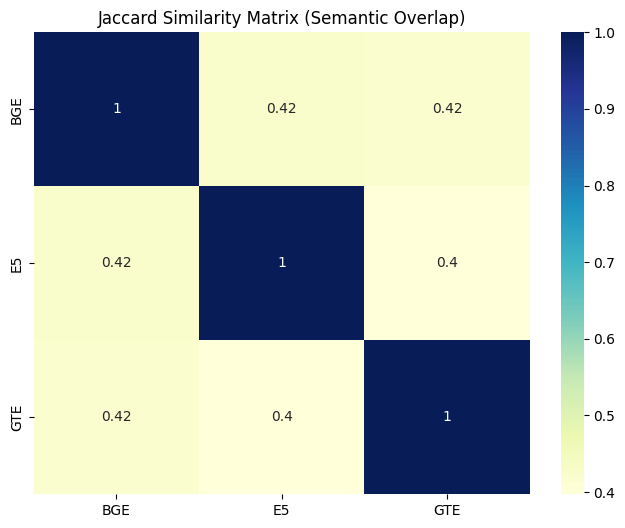

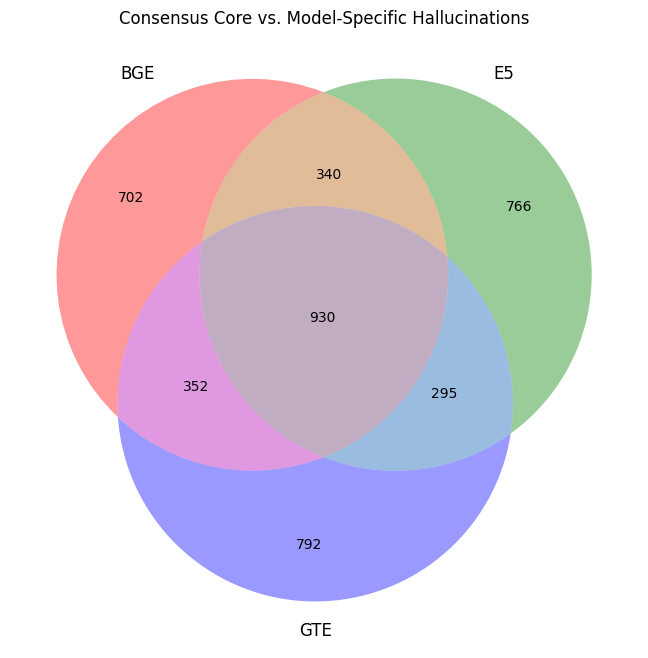

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# 1. Define once (Update these only)
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187190_task0_20260206_190324.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187191_task0_20260206_190320.jsonl"
}

# 2. Run reports automatically for each
for model_name, file_path in PATHS.items():
    print(f"\n--- {model_name} ---")
    if file_path.exists():
        gen_report(str(file_path))
    else:
        print(f"Error: File for {model_name} not found at {file_path}")
def load_data(filepath):
    data = {}
    if not filepath.exists(): return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            data[obj['job_id']] = set(obj['final'])
    return data

# 1. Load and Intersect
results = {name: load_data(path) for name, path in PATHS.items()}
loaded = [n for n, d in results.items() if d]
common_ids = set.intersection(*[set(results[m].keys()) for m in loaded])

# 2. Extract Commonalities and Differences
report_data = []
for jid in common_ids:
    bge_set = results["BGE"].get(jid, set())
    e5_set = results["E5"].get(jid, set())
    gte_set = results["GTE"].get(jid, set())
    
    # Are they identical?
    all_agree = (bge_set == e5_set == gte_set)
    
    # Who is the outlier?
    outlier = "None"
    if bge_set == e5_set != gte_set: outlier = "GTE"
    elif bge_set == gte_set != e5_set: outlier = "E5"
    elif e5_set == gte_set != bge_set: outlier = "BGE"
    elif not all_agree: outlier = "All Diverged"

    report_data.append({
        "job_id": jid,
        "all_agree": all_agree,
        "outlier": outlier,
        "bge_count": len(bge_set),
        "e5_count": len(e5_set),
        "gte_count": len(gte_set),
        "consensus_count": len(bge_set & e5_set & gte_set)
    })

df = pd.DataFrame(report_data)

# 3. Print Statistical Summary
print("=== COMPREHENSIVE COMPARISON REPORT ===")
print(f"Total Common Jobs: {len(df)}")
print(f"Absolute Consensus: {df['all_agree'].sum()} ({df['all_agree'].mean():.1%})")
print("\n--- Outlier Frequency (Who disagrees with the majority?) ---")
print(df[df['outlier'] != "None"]['outlier'].value_counts())

# 4. Generate Visualizations
# Jaccard Heatmap
model_names = list(results.keys())
j_matrix = np.zeros((3, 3))
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        scores = [len(results[m1][jid] & results[m2][jid]) / len(results[m1][jid] | results[m2][jid]) 
                  for jid in common_ids]
        j_matrix[i, j] = np.mean(scores)

plt.figure(figsize=(8, 6))
sns.heatmap(j_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Jaccard Similarity Matrix (Semantic Overlap)")
plt.savefig("semantic_overlap_heatmap.png")

# Venn Diagram
venn_sets = []
for name in model_names:
    s = set()
    for jid in common_ids:
        for occ in results[name][jid]:
            s.add(f"{jid}|{occ}")
    venn_sets.append(s)

plt.figure(figsize=(10, 8))
venn3(venn_sets, set_labels=model_names)
plt.title("Consensus Core vs. Model-Specific Hallucinations")
plt.savefig("assignment_venn.png")

In [13]:

notebook_name ='09_prompt'

In [15]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 1. EXACT CONFIGURATION
PATHS = {
    "BGE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187189_task0_20260206_190324.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz",
    },
    "E5": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187190_task0_20260206_190324.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    },
    "GTE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2187191_task0_20260206_190320.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz",
    },
}

# 2. HELPER FUNCTIONS
def _to_str_array(x: np.ndarray) -> np.ndarray:
    if x.dtype == object:
        return np.array([v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v) for v in x])
    if np.issubdtype(x.dtype, np.bytes_):
        return np.array([v.decode("utf-8") for v in x])
    return x.astype(str)

def load_meta_from_npz(npz_path: str) -> pd.DataFrame:
    with np.load(npz_path, allow_pickle=True) as npz:
        job_id_key = "job_id" if "job_id" in npz.files else ("job_ids" if "job_ids" in npz.files else None)
        title_key = "job_ad_title" if "job_ad_title" in npz.files else ("title" if "title" in npz.files else None)
        domain_key = "domain" if "domain" in npz.files else None
        sector_key = "job_sector_category" if "job_sector_category" in npz.files else None

        meta = {
            "job_id": _to_str_array(npz[job_id_key]),
            "title": _to_str_array(npz[title_key]),
        }
        meta["domain"] = _to_str_array(npz[domain_key]) if domain_key else ""
        meta["sector"] = _to_str_array(npz[sector_key]) if sector_key else ""
    return pd.DataFrame(meta)

def load_results_from_jsonl(jsonl_path: str) -> pd.DataFrame:
    rows = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except: continue

    df = pd.DataFrame(rows)
    df["job_id"] = df["job_id"].astype(str)

    if "final" in df.columns: df = df.rename(columns={"final": "kept"})
    if "drop" in df.columns: df = df.rename(columns={"drop": "dropped"})
    
    if "kept" not in df.columns: df["kept"] = None
    if "dropped" not in df.columns: df["dropped"] = None

    def _list_to_csv(x):
        if isinstance(x, list): return ", ".join(map(str, x))
        return "" if x is None else str(x)

    df["kept"] = df["kept"].apply(_list_to_csv)
    df["dropped"] = df["dropped"].apply(_list_to_csv)
    return df[["job_id", "kept", "dropped"]]

# 3. CORE BUILDER
def build_audit_dataset(paths_by_model: dict, n_jobs_per_model: int = 100, seed: int = 42) -> pd.DataFrame:
    all_frames = []
    for model, p in paths_by_model.items():
        print(f"Lendo dados para {model}...")
        meta = load_meta_from_npz(p["npz"])
        res = load_results_from_jsonl(p["jsonl"])
        
        merged = res.merge(meta, on="job_id", how="inner")
        if merged.empty:
            print(f"!!! [AVISO] {model} resultou em merge vazio.")
            continue
            
        sample_size = min(n_jobs_per_model, len(merged))
        sampled = merged.sample(n=sample_size, random_state=seed).copy()
        sampled["model"] = model
        all_frames.append(sampled)

    out = pd.concat(all_frames, ignore_index=True)
    cols = ["job_id", "model", "title", "domain", "sector", "kept", "dropped"]
    for c in cols:
        if c not in out.columns: out[c] = ""
            
    return out[cols].sort_values(["model", "job_id"]).reset_index(drop=True)

# 4. EXECUTION
if __name__ == "__main__":
    # Dinamicamente tenta pegar o nome do arquivo/notebook
    try:
        # Se for um script .py
        prefix = Path(__file__).stem
    except NameError:
        # Fallback para Jupyter Notebook (ajuste manualmente se preferir)
        prefix = notebook_name

    # Gera o dataset
    audit_df = build_audit_dataset(PATHS, n_jobs_per_model=100, seed=42)
    
    # Define o nome do arquivo com o prefixo
    out_filename = f"{prefix}_sanity_check_300_jobs_FINAL.csv"
    out_path = Path(out_filename)
    
    # Salva o CSV
    audit_df.to_csv(out_path, index=False)
    
    print("-" * 30)
    print(f"[SUCESSO] Arquivo escrito: {out_path}")
    print(f"Total de linhas: {len(audit_df)}")
    print(f"Distribuição por modelo:\n{audit_df['model'].value_counts()}")
    print("-" * 30)

Lendo dados para BGE...
Lendo dados para E5...
Lendo dados para GTE...
------------------------------
[SUCESSO] Arquivo escrito: 09_prompt_sanity_check_300_jobs_FINAL.csv
Total de linhas: 300
Distribuição por modelo:
model
BGE    100
E5     100
GTE    100
Name: count, dtype: int64
------------------------------


In [16]:
import pandas as pd
import re
import ast

# =============================================================================
# Load
# =============================================================================
file_path = "09_prompt_sanity_check_300_jobs_FINAL.csv"
df = pd.read_csv(file_path)

# Normalise model names so pivot columns are predictable
df["model"] = df["model"].astype(str).str.strip().str.lower()

# =============================================================================
# Robust parser for `kept` (handles: "['a','b']" AND "a, b")
# =============================================================================
def parse_kept(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    # Case 1: Python list literal
    if s.startswith("[") and s.endswith("]"):
        try:
            out = ast.literal_eval(s)
            if isinstance(out, list):
                return [str(i).strip() for i in out if str(i).strip()]
        except Exception:
            pass

    # Case 2: plain comma-separated
    items = re.split(r",\s*(?=[A-Z0-9])", s)
    return [i.strip().strip("[]'\"") for i in items if i.strip()]

df["kept_list"] = df["kept"].apply(parse_kept)

# =============================================================================
# Pivot: one row per job, one column per model
# =============================================================================
pivot = df.pivot_table(
    index=["job_id", "title", "domain", "sector"],
    columns="model",
    values="kept_list",
    aggfunc="first"
).reset_index()

need_models = ['bge', 'e5', 'gte']
missing_cols = [c for c in need_models if c not in pivot.columns]
if missing_cols:
    raise ValueError(
        f"Missing model columns in pivot: {missing_cols}. "
        f"Available: {sorted([c for c in pivot.columns if c not in ['job_id','title','domain','sector']])}"
    )

pivot = pivot.dropna(subset=need_models)

# =============================================================================
# Helpers
# =============================================================================
def top1(lst):
    return lst[0] if isinstance(lst, list) and len(lst) else None

def jaccard(a, b):
    sa = set(a) if isinstance(a, list) else set()
    sb = set(b) if isinstance(b, list) else set()
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / len(sa | sb)

# =============================================================================
# Divergence metrics
# =============================================================================
pivot["top1_bge"] = pivot["bge"].apply(top1)
pivot["top1_e5"]  = pivot["e5"].apply(top1)
pivot["top1_gte"] = pivot["gte"].apply(top1)

pivot["all_top1_same"] = (
    (pivot["top1_bge"] == pivot["top1_e5"]) &
    (pivot["top1_bge"] == pivot["top1_gte"])
)

pivot["jac_bge_e5"] = pivot.apply(lambda r: jaccard(r["bge"], r["e5"]), axis=1)
pivot["jac_bge_gte"] = pivot.apply(lambda r: jaccard(r["bge"], r["gte"]), axis=1)
pivot["jac_e5_gte"] = pivot.apply(lambda r: jaccard(r["e5"], r["gte"]), axis=1)

pivot["avg_jaccard"] = pivot[["jac_bge_e5", "jac_bge_gte", "jac_e5_gte"]].mean(axis=1)

# =============================================================================
# Most divergent jobs
# =============================================================================
divergent = pivot.sort_values(
    by=["avg_jaccard", "all_top1_same"],
    ascending=[True, True]
).head(20)

divergent[[
    "job_id",
    "title",
    "top1_bge",
    "top1_e5",
    "top1_gte",
    "avg_jaccard",
    "jac_bge_e5",
    "jac_bge_gte",
    "jac_e5_gte",
]]


model,job_id,title,top1_bge,top1_e5,top1_gte,avg_jaccard,jac_bge_e5,jac_bge_gte,jac_e5_gte
29,2744113462,Information Governance Officer - Police,Information Security Engineers,Regulatory Affairs Specialists,Security Managers,0.000000,0.000000,0.000000,0.000000
30,2746699682,Case Manager - Fully Remote Working,Healthcare Social Workers,Occupational Therapists,Occupational Health and Safety Specialists,0.000000,0.000000,0.000000,0.000000
44,2777345492,Culture Consultant – People Comms & Engagement...,Human Resources Managers,Compensation and Benefits Managers,Training and Development Specialists,0.000000,0.000000,0.000000,0.000000
50,2790612570,Window Cleaners,Helpers--Painters,Janitors and Cleaners,Maids and Housekeeping Cleaners,0.000000,0.000000,0.000000,0.000000
52,2790925260,Progressed Social Worker,Child,Healthcare Social Workers,Mental Health and Substance Abuse Social Workers,0.083333,0.000000,0.000000,0.250000
0,2192398821,Driving Instructor Trainee,Adult Basic Education,Cleaners of Vehicles and Equipment,Adult Basic Education,0.133333,0.000000,0.400000,0.000000
10,2669419357,HGV Technician,Recreational Vehicle Service Technicians,Transportation Inspectors,Bus and Truck Mechanics and Diesel Engine Spec...,0.133333,0.400000,0.000000,0.000000
34,2751637709,Warehouse / Stores Despatch Assistant,Weighers,Inspectors,Medical Equipment Repairers,0.144444,0.333333,0.000000,0.100000
26,2738958402,Senior Investment Broker,Financial Managers,Securities,Securities,0.150000,0.000000,0.200000,0.250000
45,2780613096,Frontend Engineering Leader (OPEN TO UK REMOTE),Architectural and Engineering Managers,Architectural and Engineering Managers,Training and Development Managers,0.150000,0.250000,0.000000,0.200000
